<a href="https://colab.research.google.com/github/fsasanian/Pytorch-Tutorial/blob/main/Intro_to_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import torch

In [60]:
!pip list

Package                                  Version
---------------------------------------- -------------------
absl-py                                  1.4.0
accelerate                               1.13.0
access                                   1.1.10.post3
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.4
aiosignal                                1.4.0
aiosqlite                                0.22.1
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.18.4
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                         

In [61]:
my_torch = torch.arange(10)
my_torch

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [62]:
# with reshape and view, they will update
my_torch = my_torch.reshape(2,5)
my_torch

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [63]:
my_torch2 = torch.arange(10)
my_torch2

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [64]:
# Reshape if we don't know the number of items using -1
my_torch2 = my_torch2.reshape(2,-1)
my_torch2

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [65]:

my_torch2[1] = 41
my_torch2

tensor([[ 0,  1,  2,  3,  4],
        [41, 41, 41, 41, 41]])

In [66]:
# Slice
my_torch3 = torch.arange(10)
my_torch3

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [67]:
# Grab a specific item
my_torch3[7]

tensor(7)

In [68]:
# Grab a slice
my_torch4 = my_torch3.reshape(5,2)
my_torch4


tensor([[0, 1],
        [2, 3],
        [4, 5],
        [6, 7],
        [8, 9]])

In [69]:
my_torch4[:,1]

tensor([1, 3, 5, 7, 9])

In [70]:
# Return column
my_torch4[:,1:]

tensor([[1],
        [3],
        [5],
        [7],
        [9]])

In [71]:
# Create a basic Neural Network

In [72]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [73]:
# Create a Model Class that inherits nn.Module
class Model(nn.Module):
  # Input layers (4 features of the flower)-->
# Hidden layer1 -->
# H2(n) -->
# Output (3 Classes of irish flowers)
    def __init__(self, in_features=4, h1=8,h2=9, out_features=3):
      super().__init__()
      self.fc1 = nn.Linear(in_features, h1)
      self.fc2 = nn.Linear(h1,h2)
      self.out = nn.Linear(h2, out_features)

    def forward(self, x):
     x = F.relu(self.fc1(x))
     x = F.relu(self.fc2(x))
     x = self.out(x)
     return x

In [74]:
# pick a manual seed for randomazation
torch.manual_seed(41)
model = Model()


In [75]:
# Load Data & train Neural Network Model

In [76]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd

In [77]:
url = "https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv"
my_df = pd.read_csv(url)
my_df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [78]:
#Change last column from string to integers
my_df["variety"] = my_df["variety"].replace({"Setosa":0, "Versicolor":1, "Virginica":2})
my_df

/tmp/ipykernel_1344/3452246198.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df["variety"] = my_df["variety"].replace({"Setosa":0, "Versicolor":1, "Virginica":2})


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [79]:
# Train Test Split! Set X, Y
X = my_df.drop("variety", axis=1)
Y = my_df["variety"]

In [80]:
X

,sepal.length,sepal.width,petal.length,petal.width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [81]:
Y

,variety
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [82]:
# Convert these to numuy arrays
X = X.values
Y = Y.values

In [83]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [84]:
from sklearn.model_selection import train_test_split

In [85]:
#Train Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=41)

In [86]:
# Convert X feature to Float tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [87]:
# Convert Y lables to tensor long
Y_train = torch.LongTensor(Y_train)
Y_test = torch.LongTensor(Y_test)

In [88]:
# Set the criterian of model to measure the error, how
#far off the predictions as from the data
criterian = nn.CrossEntropyLoss()
# Choose Adam Optimizer, lr = learning rate (if
# error doesnt go down after a bunch of iteration(epochs),
# lower our learning rate)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [89]:
# Train our model!
# Epochs? (one run thru all the training data in our network)
epochs= 100
losses = []
for i in range(epochs):
  # Go forward and get a prediction
  y_pred = model.forward(X_train) #Get predicted result

  #measure the loss/error, ganna be high at first
  loss = criterian(y_pred, Y_train) # predictied values vs the y-train

  #keep track of our losses
  losses.append(loss.detach().numpy())

  #print evry 10 epoch
  if i%10 == 0:
    print(f"Epoch: {i} Loss: {loss}")

    #Do some back propagation: take the error rate
    # of forward propagattion and feed it back thru the network to fine tune the wights
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch: 0 Loss: 1.125203251838684
Epoch: 10 Loss: 1.1235824823379517
Epoch: 20 Loss: 1.1219687461853027
Epoch: 30 Loss: 1.1203668117523193
Epoch: 40 Loss: 1.1187783479690552
Epoch: 50 Loss: 1.1171947717666626
Epoch: 60 Loss: 1.1156123876571655
Epoch: 70 Loss: 1.1140543222427368
Epoch: 80 Loss: 1.1125227212905884
Epoch: 90 Loss: 1.1109986305236816


Text(0.5, 0, 'Epoch')

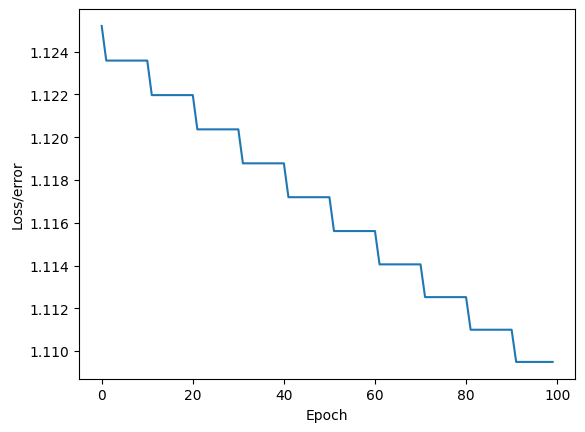

In [90]:
# Grap it out
plt.plot(range(epochs), losses)
plt.ylabel("Loss/error")
plt.xlabel("Epoch")